In [2]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap

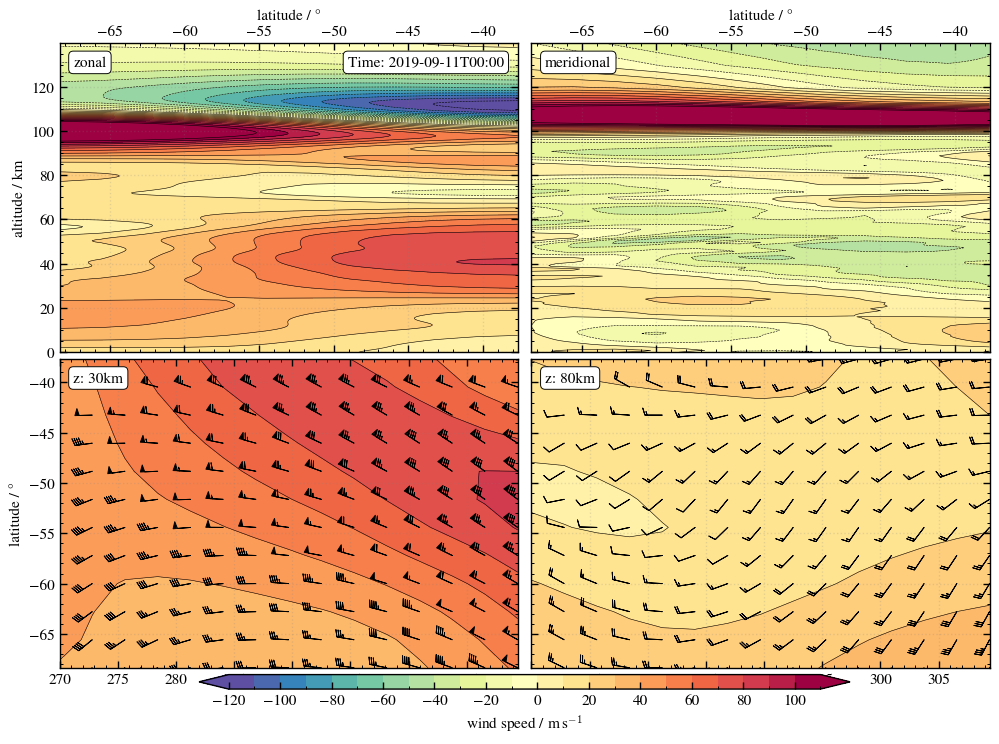

In [6]:
"""Animation of meridional cross section"""
def plt_meridional_slice(t, ds, folder):

    animation = True
    wind_levels = np.arange(-120,120,10)
    wind_labels = np.arange(-120,120,20)
    cmap_wind = plt.get_cmap('Spectral_r')
    # cmap_wind = plt.get_cmap('RdBu_r')
    norm_wind = BoundaryNorm(boundaries=wind_levels, ncolors=cmap_wind.N, clip=True)

    gskw  = {'wspace': 0.03, 'hspace':0.03, 'height_ratios': [5,5,1], 'width_ratios': [1,1]}
    fig, axes = plt.subplots(3,2, figsize=(12,9), gridspec_kw=gskw)
    ax0 = axes[0,0]
    ax1 = axes[0,1]
    ax2 = axes[1,0]
    ax3 = axes[1,1]

    axes[-1,0].axis('off')
    axes[-1,1].axis('off')

    lon = 281
    dsyz = ds.sel(longitude=lon, method='nearest')
    # ds = ds.sel(latitude=lats)

    contf = ax0.contourf(dsyz['latitude'].values, dsyz['level'].values/1000, dsyz['u'].sel(time=dsyz.time[t]).values, 
                                    levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont  = ax0.contour(dsyz['latitude'].values, dsyz['level'].values/1000, dsyz['u'].sel(time=dsyz.time[t]).values, 
                                    levels=wind_levels, colors='black', linewidths=0.4, norm=norm_wind, extend='both') 
    contf = ax1.contourf(dsyz['latitude'].values, dsyz['level'].values/1000, dsyz['v'].sel(time=dsyz.time[t]).values, 
                                    levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont  = ax1.contour(dsyz['latitude'].values, dsyz['level'].values/1000, dsyz['v'].sel(time=dsyz.time[t]).values, 
                                    levels=wind_levels, colors='black', linewidths=0.4, norm=norm_wind, extend='both') 

    nbarbs = 1
    lev1 = 30000
    lev2 = 80000
    u30 = (ds['u'].sel(time=ds.time[t], level=lev1).values**2 + ds['v'].sel(time=ds.time[t], level=lev1).values**2)**0.5

    contf = ax2.contourf(ds['longitude'].values, ds['latitude'].values, u30, 
                                    levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both')
    cont  = ax2.contour(ds['longitude'].values, ds['latitude'].values, u30, 
                                    levels=wind_levels, colors='black', linewidths=0.4, norm=norm_wind, extend='both')     
    barbs_met  = ax2.barbs(ds['longitude'].values[::nbarbs], ds['latitude'].values[::nbarbs], ds['u'].sel(time=ds.time[t], level=lev1).values[::nbarbs,::nbarbs], ds['v'].sel(time=ds.time[t], level=lev1).values[::nbarbs,::nbarbs], length=5, linewidth=0.7)

    u80 = (ds['u'].sel(time=ds.time[t], level=lev2).values**2 + ds['v'].sel(time=ds.time[t], level=lev2).values**2)**0.5
    contf = ax3.contourf(ds['longitude'].values, ds['latitude'].values, u80, 
                                    levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both')
    cont  = ax3.contour(ds['longitude'].values, ds['latitude'].values, u80, 
                                    levels=wind_levels, colors='black', linewidths=0.4, norm=norm_wind, extend='both') 
    barbs_met  = ax3.barbs(ds['longitude'].values[::nbarbs], ds['latitude'].values[::nbarbs], ds['u'].sel(time=ds.time[t], level=lev2).values[::nbarbs,::nbarbs], ds['v'].sel(time=ds.time[t], level=lev2).values[::nbarbs,::nbarbs], length=5, linewidth=0.7)


    for ax in axes.flatten():
        ax.yaxis.set_minor_locator(AutoMinorLocator()) 
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.grid()

    ax0.xaxis.set_label_position('top')
    ax1.xaxis.set_label_position('top')

    ax0.tick_params(which='both', labelbottom=False,labeltop=True)
    ax1.tick_params(which='both', labelbottom=False,labeltop=True,labelleft=False)
    ax3.tick_params(which='both', labelbottom=True,labelleft=False)

    ax0.set_ylabel('altitude / km')
    ax2.set_ylabel('latitude / °')
    # ax0.set_ylim(vert_range_lid)
    # ax0.set_xlim(ds_ml['time'].values[0],ds_ml['time'].values[-1])
    ax0.set_xlabel("latitude / °")
    ax1.set_xlabel("latitude / °")
    
    cbar = fig.colorbar(contf, ax=axes[-1,:], location='bottom', ticks=wind_labels, shrink=0.7, fraction=1, aspect=45)
    cbar.set_label(r"wind speed / m$\,$s$^{-1}$")

    
    ax0.text(0.03, 0.96, f"zonal", transform=ax0.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    
    ax1.text(0.03, 0.96, f"meridional", transform=ax1.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

    ax2.text(0.03, 0.96, f"z: 30km", transform=ax2.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    
    ax3.text(0.03, 0.96, f"z: 80km", transform=ax3.transAxes, 
                 verticalalignment='top', horizontalalignment='left',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

    ax0.text(0.97, 0.96, f"Time: {datetime.datetime.strftime(ds.time[t].values.astype('datetime64[us]').item(),format='%Y-%m-%dT%H:%M')}", transform=ax0.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    
    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    if animation:   
        fig_name = 'meriodional_slice_' + '{:02d}'.format(t) + '.png'
    else:
        fig_name = 'meridional_slice.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')


#ds = xr.open_dataset(os.path.join("/export/data2/model/jawara","jawara_patagonia_180616.nc"))
ds = xr.open_dataset(os.path.join("/export/data2/model/jawara","jawara_patagonia_190911.nc"))

#folder = "./data/jawara-winds-180616"
folder = "./data/jawara-winds-st08"

lats = slice(-38, -62)
lons = slice(278,288)


# ds = ds.sel(latitude=lats, longitude=lons).mean(dim="longitude")
var = 'u'
sigma = 3
ds[var].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=1)
ds[var].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=2)

os.makedirs(folder, exist_ok="True")
plt_meridional_slice(0, ds, folder)

In [7]:
%%capture
print(f"Plotting {len(ds.time)} slices...")
for t in range(0, len(ds.time)):
    plt_meridional_slice(t, ds, folder)
plt_helper.create_animation(folder,os.path.join(folder,"animation-jawara-slice.mp4"),fps=3)

In [25]:
"""Meridional cross section"""
lats = slice(-56,-60)
lons = slice(277,287)
lon = 282 

ds        = xr.open_dataset("../data/eulag/era5_ml_T21_int.nc")
ds_jawara = xr.open_dataset(os.path.join("/export/data2/model/jawara/2018","jawara_patagonia_180616.nc"))
# ds = ds.sel(latitude=lats, longitude=lons)
# ds_jawara = ds_jawara.sel(lat=lats, lon=lons)

wind_levels = np.arange(-150,150,10)
cmap_wind = plt.get_cmap('Spectral_r')
cmap_wind = plt.get_cmap('RdBu_r')
norm_wind = BoundaryNorm(boundaries=wind_levels, ncolors=cmap_wind.N, clip=True)

gskw  = {'hspace':0.06, 'height_ratios': [5,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(2,1, figsize=(10,8), gridspec_kw=gskw)
ax0 = axes[0]
ax1 = axes[1]
ax1.axis('off')

yzslice = ds_jawara['u'].mean(dim=["time"]).sel(longitude=lon, method="nearest").values

contf = ax0.contourf(ds_jawara['latitude'].values, ds_jawara['level'].values/1000, yzslice, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
cont = ax0.contour(ds['latitude'].values, ds['level'].values/1000, ds['u'].mean(dim=["time"]).sel(longitude=lon, method="nearest").values, levels=wind_levels, colors='k', linewidths=0.4) # BW

ax0.yaxis.set_minor_locator(AutoMinorLocator()) 
ax0.xaxis.set_minor_locator(AutoMinorLocator())

ax0.xaxis.set_label_position('top')
ax0.tick_params(which='both', labelbottom=False,labeltop=True)
ax0.set_ylabel('altitude / km')
# ax0.set_ylim(vert_range_lid)
# ax0.set_xlim(ds_ml['time'].values[0],ds_ml['time'].values[-1])
ax0.set_xlabel("Latitude / °")
ax0.grid()
cbar = fig.colorbar(contf, ax=ax1, location='bottom', ticks=wind_levels, shrink=0.7, fraction=1, aspect=30)
cbar.set_label(r"U / m$\,$s$^{-1}$")

FileNotFoundError: [Errno 2] No such file or directory: '/export/data2/model/eulag/data/eulag/era5_ml_T21_int.nc'